# Next-day sales for discounted perishables

**Should a category manager discount a perishable product tomorrow?** This notebook builds and compares models that predict next-day sales for a store-product given tomorrow's discount, so that the question can eventually be answered by feeding candidate discounts into the best model (phase 2).

It is written to be read top to bottom. Each section states what was done, shows the numbers, and records the decision taken and why. The code that does the work lives in the small package under `src/finalproject_pricingml/`; the cells here only call it, so the story stays readable.

| Section | What it covers |
|---|---|
| 1–2 | Goal and data |
| 3–7 | Series selection, features, splits, metrics, baseline |
| 8 | k-nearest neighbours: tuning, locked design |
| 9 | Random forest: tuning, locked design |
| 10–11 | CatBoost and a forest + CatBoost ensemble (next models to test) |
| 12 | Comparison on the validation weeks and the unseen test week |
| 13–14 | Findings, limits, next steps |

In [1]:
import pandas as pd
from IPython.display import display

from finalproject_pricingml import config as C, data, evaluate as ev, models, plots

# Set to True to recompute every tuning grid from the feature table (about a minute in total).
# When False, the grids are read back from results/ and only the final test-week models are fitted.
RERUN_TUNING = False

pd.set_option("display.precision", 4)
pd.set_option("display.width", 140)

## 1. Goal

Help a Dingdong category manager decide whether to discount a perishable product tomorrow, by predicting next-day sales for a store-product given tomorrow's discount.

- **Success test:** lower next-day sales error than a simple baseline.
- **Phase 2 (after the best model is chosen):** feed candidate discount rates into the model to suggest a discount. This is a model-based claim, not something the data can verify.

Two limits set by the data:

- The dataset has one discount rate per day, with no intraday markdown. "End-of-day discount" therefore means "tomorrow's daily discount".
- Discounts were not assigned at random, so the model's response to discount is a correlation, not a proven cause.

## 2. Data

Source: [FreshRetailNet-50K](https://huggingface.co/datasets/Dingdong-Inc/FreshRetailNet-50K) (Dingdong, Hugging Face, CC BY 4.0). The two parquet files are not in the repository; put them in `data/raw/` (see the README).

| Item | Value |
|---|---|
| Series (store-product) | 50,000 |
| Stores / cities / products | 898 / 18 / 865 |
| Training period | 90 days, 2024-03-28 to 2024-06-25 (`train.parquet`) |
| Unseen test period | 7 days, 2024-06-26 to 2024-07-02 (`eval.parquet`) |
| Missing values | None |
| Rows with no discount (exactly 1.0) | About 48% |
| Rows with at least one stockout hour | 44% |

- `sale_amount` is normalised, not real units, so errors only mean something relative to a baseline.
- Stockouts mean recorded sales understate true demand on those days. Stockout days were kept.

## 3. Store and product selection

The model needs series where the discount actually varies. A day counts as "discounted" when the discount is below 0.95. A series is usable when:

- it is discounted on 15–85% of days (removes never- and always-discounted products),
- it switches between discounted and not at least 6 times,
- it has zero sales on fewer than 20% of days.

Across the full dataset, 4,997 series are never discounted, 1,872 are always discounted, and 16,684 of 50,000 pass. To keep the first models small the working set is the five stores with the most usable series, all in city 0. (`data.select_series` scores every series; the result is cached in `data/processed/selected_series.csv`.)

In [2]:
feat = data.load_features()  # builds data/processed/ from the raw parquet files on first use
selected = pd.read_csv(C.PROCESSED / "selected_series.csv")

stores = selected.groupby("store_id").agg(city=("city_id", "first"), usable_series=("product_id", "size"))
display(stores.sort_values("usable_series", ascending=False))
print(f"Working set: {len(selected)} series, {selected.product_id.nunique()} products, {len(feat):,} rows after building features")

,city,usable_series
store_id,,
18,0,64
343,0,64
235,0,63
182,0,61
154,0,60


Working set: 312 series, 122 products, 28,080 rows after building features


## 4. Does discount carry signal?

Before modelling: do deeper discounts go with higher sales in these series? Sales are expressed relative to each series' own average so that products of different size can be pooled.

In [3]:
rel = feat.assign(relative_sales=feat[C.TARGET] / feat.groupby(C.KEY)[C.TARGET].transform("mean"))
bands = pd.cut(rel.discount_next, [0, 0.6, 0.7, 0.8, 0.9, 0.95, 1.0],
               labels=["below 0.6", "0.6–0.7", "0.7–0.8", "0.8–0.9", "0.9–0.95", "0.95–1.0 (none)"])
display(rel.groupby(bands, observed=True).agg(rows=("relative_sales", "size"), relative_sales=("relative_sales", "mean")).round(2))

,rows,relative_sales
discount_next,,
below 0.6,203,3.00
0.6–0.7,862,1.50
0.7–0.8,1980,1.35
0.8–0.9,5889,1.13
0.9–0.95,3646,1.03
0.95–1.0 (none),15500,0.84


Sales rise steadily as the discount deepens. Tomorrow's discount is worth modelling.

## 5. Target and features

**Target:** sales on day t+1 for the same store and product. One row is one store-product-day. Every feature is known on the evening of day t, when the discount decision is made.

**Why history features are needed.** The raw columns describe the day, not the product. kNN with raw columns only scored MAE 0.558 against a baseline of 0.339 in an early check; adding the product's own sales history brought it to 0.364.

**Locked feature set (10):**

| Feature | Column | Day |
|---|---|---|
| Sales | `sales_t` | t |
| Sales 7 days before the target day | `sales_lag7` | t−6 |
| Mean sales over the last 7 days | `sales_mean7` | up to t |
| Mean sales to date | `sales_mean_to_date` | up to t |
| Stockout hours | `stockout_hours_t` | t |
| Discount | `discount_t` | t |
| Discount (the manager's decision) | `discount_next` | t+1 |
| Activity flag | `activity_t` | t |
| Holiday flag | `holiday_next` | t+1 |
| Weekday | `weekday_next` | t+1 |

**Considered and left out:**

| Item | Reason |
|---|---|
| Weather on day t (rain, temperature, humidity) | Removing it lowered error for both kNN and the forest (sections 8 and 9) |
| Weather on day t+1 | No gain; 0.88–0.97 correlated with day t |
| Activity flag on day t+1 | No gain; largely repeats tomorrow's discount (92% of activity days are discounted) |
| Stockout hours on day t+1 | Not known in advance; would leak the answer |
| Hourly sales and stock lists, product ids | Excluded from the first models by design |

In [4]:
display(feat[C.ROW_KEY + C.FEATURES + [C.TARGET]].head())
display(feat[C.FEATURES + [C.TARGET]].describe().T[["mean", "std", "min", "max"]].round(2))

,store_id,product_id,dt,sales_t,sales_lag7,sales_mean7,sales_mean_to_date,stockout_hours_t,discount_t,discount_next,activity_t,holiday_next,weekday_next,target_sales
0,18,11,2024-04-04,0.2,0.9,0.9000,0.9000,0.0,0.833,0.833,1.0,1,3,1.2
1,18,11,2024-04-05,1.2,0.6,0.9429,0.9375,7.0,0.833,0.833,1.0,1,4,0.9
2,18,11,2024-04-06,0.9,1.7,0.9857,0.9333,0.0,0.833,0.833,1.0,1,5,1.3
3,18,11,2024-04-07,1.3,1.5,0.9286,0.9700,8.0,0.833,0.833,1.0,0,6,1.2
4,18,11,2024-04-08,1.2,0.5,0.8857,0.9909,8.0,0.833,0.833,1.0,0,0,1.1


,mean,std,min,max
sales_t,0.88,0.83,0.00,10.60
sales_lag7,0.86,0.79,0.00,10.20
sales_mean7,0.87,0.68,0.00,7.47
sales_mean_to_date,0.79,0.50,0.07,3.81
stockout_hours_t,3.23,4.43,0.00,16.00
discount_t,0.93,0.10,0.26,1.00
discount_next,0.93,0.10,0.26,1.00
activity_t,0.40,0.49,0.00,1.00
holiday_next,0.34,0.48,0.00,1.00
weekday_next,3.01,2.01,0.00,6.00


## 6. Cleaning and splits

- No duplicate store-product-days, no date gaps, no missing values in the 312 series (asserted in `data.build_features`).
- Days with a discount of exactly 0 are treated as give-aways or data artefacts: their sales are blanked so they never feed a lag or a target.
- The first 7 days of each series are dropped because the 7-day features need a full week.
- Standardization (where a model needs it) is fitted on the training rows of each fold only.

Splits are by time. For each validation week the model trains on every row dated before that week. The test week comes from `eval.parquet` and is touched exactly once per model, after its design is locked.

In [5]:
display(data.split_summary(feat))

rows  first_day   last_day
split val_fold                             
test  0          2184 2024-06-26 2024-07-02
train 0         14976 2024-04-04 2024-05-21
      1          2184 2024-05-22 2024-05-28
      2          2184 2024-05-29 2024-06-04
      3          2184 2024-06-05 2024-06-11
      4          2184 2024-06-12 2024-06-18
      5          2184 2024-06-19 2024-06-25

**Why not random splits.** Neighbouring days of the same product share most of their history, so random splits put near-copies on both sides and flatter the model. Mean kNN MAE over five rounds, all 13 original features (one-off check, not scripted):

| k | Time-ordered | Random, no overlap | Random with replacement |
|---|---|---|---|
| 1 | 0.429 | 0.377 | 0.139 |
| 5 | 0.342 | 0.303 | 0.261 |
| 15 | 0.327 | 0.294 | 0.280 |
| 40 | 0.327 | 0.296 | 0.291 |

Random splits also pick the wrong k: k=1 looks best with replacement and is worst in honest testing. Every result below uses the time-ordered folds.

## 7. Metrics and baseline

- **MAE:** average absolute error, in sales units. Main tuning criterion.
- **WAPE:** total absolute error divided by total sales.
- **MSE:** reported as the academic metric. It penalises large misses more heavily.

Baseline: the mean of the last 7 days' sales. It beats "same weekday last week" on every fold, so it is the bar every model has to clear.

In [6]:
train = ev.training_rows(feat)
baseline = ev.baseline_by_fold(train)
same_weekday = ev.baseline_by_fold(train, column="sales_lag7")

by_week = pd.DataFrame({"7-day average": baseline.mae, "Same weekday last week": same_weekday.mae}).rename(index=C.FOLD_LABELS)
by_week.loc["Average"] = by_week.mean()
display(by_week.round(3))

,7-day average,Same weekday last week
fold,,
May 22–28,0.309,0.385
May 29–Jun 4,0.316,0.387
Jun 5–11,0.362,0.446
Jun 12–18,0.327,0.435
Jun 19–25,0.328,0.422
Average,0.328,0.415


## 8. k-nearest neighbours

**How it works.** kNN stores the training rows. To predict a row it finds the k most similar training rows (Euclidean distance on standardized features) and averages their sales. There is no training step and no loss curve: k is a setting chosen by validation, not a parameter learned by gradient descent.

All figures below are average MAE over the five validation weeks.

### Round 1: neighbours and feature weighting, with weather (13 features)

A feature weight multiplies the standardized feature, so a weight of 2 makes it count twice as much in the distance. Three weightings were tried: equal weights, a *prior* weighting from expectations (sales averages, discounts, holiday, weekday ×2), and an *evidence-led* weighting (sales averages and tomorrow's discount ×2; weather and stockout ×0.5).

In [7]:
def best_per_weighting(path):
    s = pd.read_csv(path)
    s = s[s.k > 0]
    return s.loc[s.groupby("weighting").mae.idxmin()].set_index("weighting")[["k", "mae", "wape", "mse", "folds_beating_baseline"]]

round1 = best_per_weighting(C.RESULTS / "knn_stage1_with_weather_summary.csv")
round2 = best_per_weighting(C.RESULTS / "knn_stage1_three_weightings_summary.csv")
print(f"Baseline MAE: {baseline.mae.mean():.3f}\n")
print("Round 1, with weather (13 features): best k per weighting")
display(round1)

Baseline MAE: 0.328

Round 1, with weather (13 features): best k per weighting


,k,mae,wape,mse,folds_beating_baseline
weighting,,,,,
equal,25,0.3267,0.3426,0.2544,3
evidence,25,0.3115,0.3268,0.2294,5
prior,25,0.3182,0.3338,0.2407,5


An earlier prior that boosted weather and stockout hours made the model worse (0.332 at k=15 against 0.327 for equal weights). Weighting helped here, but the next round shows why.

### Round 2: weather removed (10 features)

In [8]:
print("Round 2, without weather (10 features): best k per weighting")
display(round2)
display(pd.DataFrame({"MAE with weather": round1.mae, "MAE without weather": round2.mae}).round(3))

Round 2, without weather (10 features): best k per weighting


,k,mae,wape,mse,folds_beating_baseline
weighting,,,,,
equal,25,0.3120,0.3273,0.2375,5
evidence,25,0.3088,0.3240,0.2293,5
prior,25,0.3114,0.3267,0.2362,5


,MAE with weather,MAE without weather
weighting,,
equal,0.327,0.312
evidence,0.311,0.309
prior,0.318,0.311


- Dropping weather mattered more than any weighting.
- Once weather is gone the three weightings are within 0.003, well inside the week-to-week variation (about 0.02). **Weighting was dropped.**
- Weather has no measurable link to the day's sales lift: correlation of about −0.01 with sales divided by the 7-day average.

### The k curve (10 features)

The final grid: eight values of k, equal weights against one last weighting (sales on day t ×2). `ev.cross_validate` fits each setting on the rows before each validation week and scores that week.

k,3,5,10,15,25,40,60,100
weighting,,,,,,,,
equal,0.3468,0.3298,0.3188,0.3139,0.3120,0.3123,0.3133,0.3157
sales_t,0.3491,0.3322,0.3194,0.3156,0.3125,0.3124,0.3137,0.3167


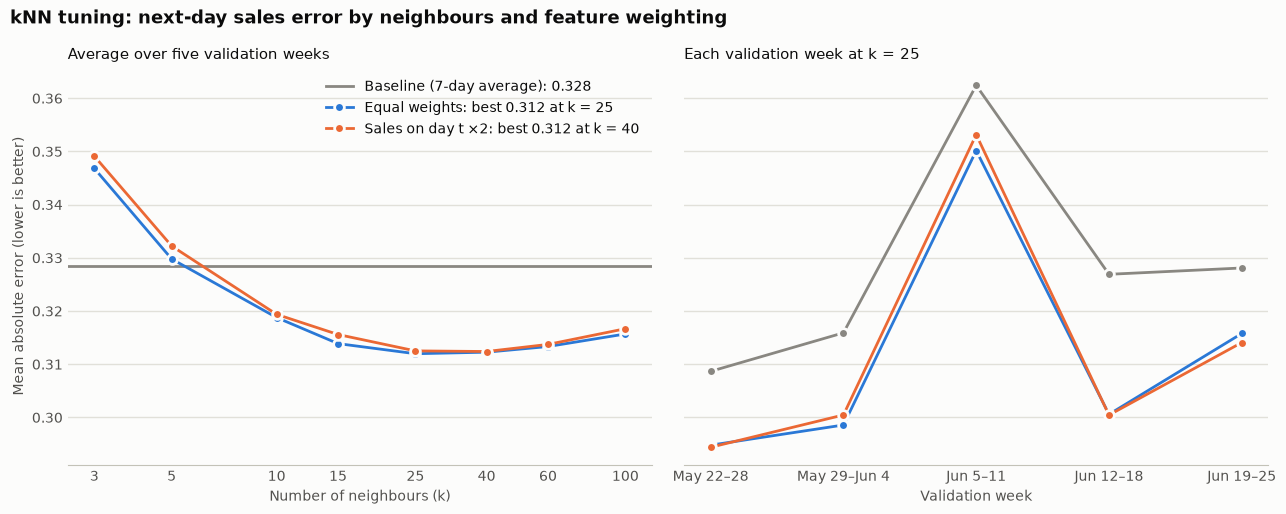

In [9]:
KNN_WEIGHTINGS = {"equal": {}, "sales_t": {"sales_t": 2}}
KNN_GRID = [{"weighting": w, "k": k} for w in KNN_WEIGHTINGS for k in (3, 5, 10, 15, 25, 40, 60, 100)]

if RERUN_TUNING:
    knn_folds = ev.cross_validate(feat, lambda weighting, k: models.make_knn(k, KNN_WEIGHTINGS[weighting]), KNN_GRID)
    knn_folds.to_csv(C.RESULTS / "knn_stage1_folds.csv", index=False)
else:
    knn_folds = pd.read_csv(C.RESULTS / "knn_stage1_folds.csv")
    knn_folds = knn_folds[knn_folds.k > 0]  # the file also holds the baseline rows

knn_summary = ev.summarise(knn_folds, ["weighting", "k"], baseline)
display(knn_summary.mae.unstack("weighting").round(4).T)

fig = plots.plot_knn_tuning(knn_folds, baseline, {"equal": ("Equal weights", C.COLOURS["knn"]), "sales_t": ("Sales on day t ×2", C.COLOURS["rf"])},
                            save=C.RESULTS / "knn_stage1.png")

Small k follows noise; large k averages over products that are too different. The bottom is flat from 15 to 60, and MSE also picks k=25.

### Further checks (one-off runs, k=25, change against 0.3120)

| Check | MAE | Change |
|---|---|---|
| Sales on day t at ×2 | 0.3125 | +0.0005 |
| Add activity t+1 and holiday t+1, both ×2 | 0.3129 | +0.0009 |
| Manhattan distance | 0.3105 | −0.0015 |
| Closer neighbours count more | 0.3115 | −0.0005 |
| Weekday as seven yes/no columns | 0.3174 | +0.0054 |
| Weekday removed | 0.3096 | −0.0024 |
| Min-max scaling | 0.3225 | +0.0105 |
| Robust scaling | 0.3103 | −0.0017 |
| Target = sales ÷ 7-day average, log-scaled features | 0.3079 | −0.0041 |
| Train on last 28 days only | 0.3156 | +0.0036 |

No option moved MAE by more than 0.004, so tuning stopped here.

### Which features carry the model (remove one at a time, k=25)

| Feature removed | Change in MAE |
|---|---|
| Discount on day t+1 | +0.0139 |
| 7-day average sales | +0.0095 |
| Sales on day t | +0.0082 |
| Average sales to date | +0.0024 |
| Discount on day t | +0.0007 |
| Sales 7 days before | +0.0004 |
| Holiday on day t+1 | +0.0001 |
| Stockout hours on day t | −0.0002 |
| Activity on day t | −0.0009 |
| Weekday of day t+1 | −0.0024 |

Tomorrow's discount is the most important single feature.

### Locked kNN design

- 10 features, standard scaling, Euclidean distance, all neighbours counted equally, **k = 25**.
- Validation: MAE 0.312, WAPE 32.7%, MSE 0.238, against baseline MAE 0.328, WAPE 34.5%, MSE 0.270. Ahead in all five weeks.

In [10]:
KNN_K = 25
knn_val = knn_folds[(knn_folds.weighting == "equal") & (knn_folds.k == KNN_K)].set_index("fold")
display(pd.DataFrame({"kNN": knn_val[["mae", "wape", "mse"]].mean(), "Baseline": baseline.mean()}).T.round(3))

,mae,wape,mse
kNN,0.312,0.327,0.237
Baseline,0.328,0.345,0.270


## 9. Random forest

**How it works.** A random forest builds many decision trees, each on a random sample of the training rows, and averages their predictions.

- **Split rule:** squared error. Each split is chosen to give the largest drop in the variance of sales in the two resulting groups. (Gini and entropy are the classification equivalents and do not apply to a continuous target.)
- **No scaling needed:** trees split on one feature at a time, so feature units do not matter.
- **No gradient descent:** trees are built by choosing splits directly, so there is no loss curve over training steps.
- **What limits over-fitting:** maximum depth and minimum rows per leaf. Either stops trees from memorising noise; they play the role k played for kNN.

All figures are average MAE over the five validation weeks, with 300 trees.

### Round 1: leaf size, features per split, weather (36 combinations, no depth limit)

In [11]:
round1_rf = pd.read_csv(C.RESULTS / "rf_tuning_leaf_features_summary.csv")
display(round1_rf.pivot_table(index=["features", "min_leaf"], columns="max_features", values="mae").round(4))
print("Combinations beating the baseline in all five weeks:", (round1_rf.folds_beating_baseline == 5).sum(), "of", len(round1_rf))

max_features             0.33    0.50    1.00
features     min_leaf                        
10 features  1         0.3057  0.3066  0.3122
             3         0.3039  0.3044  0.3089
             5         0.3037  0.3034  0.3068
             10        0.3044  0.3031  0.3050
             20        0.3064  0.3051  0.3060
             40        0.3095  0.3077  0.3085
with weather 1         0.3103  0.3116  0.3163
             3         0.3078  0.3079  0.3113
             5         0.3069  0.3062  0.3090
             10        0.3065  0.3058  0.3067
             20        0.3076  0.3067  0.3079
             40        0.3107  0.3088  0.3103

Combinations beating the baseline in all five weeks: 36 of 36


- Best setting: leaf ≥ 10, half the features per split, no weather: 0.3031. The same setting with weather: 0.3058.
- Weather made every setting worse, as it did for kNN, though by less (about 0.003 against about 0.015). **Weather stays out.**
- Every one of the 36 combinations beat the baseline in all five weeks: the forest is far less sensitive to its settings than kNN was.

### Round 2: depth and leaf size (16 combinations, half the features per split)

min_leaf,3,5,10,20
max_depth,,,,
10,0.3024,0.3027,0.3035,0.3052
15,0.3030,0.3031,0.3032,0.3049
20,0.3043,0.3036,0.3034,0.3048
No limit,0.3044,0.3034,0.3031,0.3051


min_leaf,3,5,10,20
max_depth,,,,
10,10,10,10,10
15,15,15,15,15
20,20,20,20,20
No limit,41,36,31,27


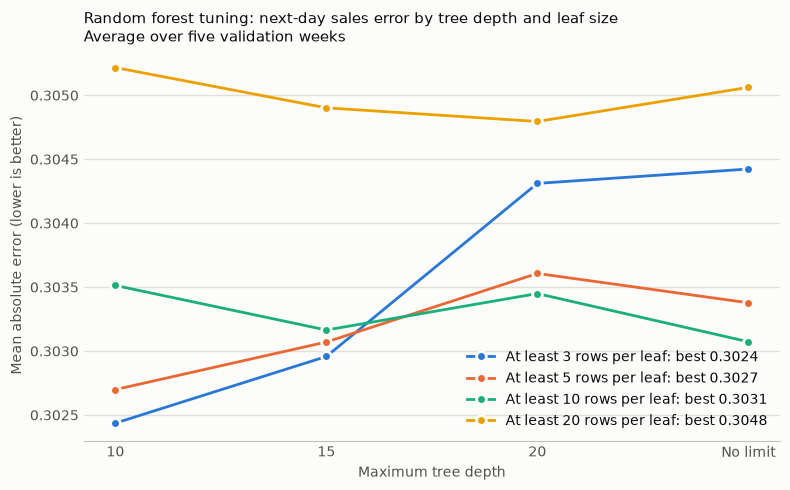

In [12]:
RF_DEPTHS, RF_LEAVES = ["10", "15", "20", "No limit"], [3, 5, 10, 20]
RF_GRID = [{"max_depth": d, "min_leaf": l} for d in RF_DEPTHS for l in RF_LEAVES]

if RERUN_TUNING:
    rf_folds = ev.cross_validate(feat, models.make_rf, RF_GRID, n_jobs=1, describe=models.tree_depth)
    rf_folds.to_csv(C.RESULTS / "rf_tuning_folds.csv", index=False)
else:
    rf_folds = pd.read_csv(C.RESULTS / "rf_tuning_folds.csv", dtype={"max_depth": str})

rf_summary = ev.summarise(rf_folds, ["max_depth", "min_leaf"], baseline, extra={"deepest_tree": ("actual_depth", "max")})
display(rf_summary.mae.unstack("min_leaf").reindex(RF_DEPTHS).round(4))
display(rf_summary.deepest_tree.unstack("min_leaf").reindex(RF_DEPTHS))

fig = plots.plot_rf_tuning(rf_summary, RF_DEPTHS, RF_LEAVES, save=C.RESULTS / "rf_tuning.png")

- The whole grid spans 0.003, about a seventh of the week-to-week variation (0.02). The plot's vertical axis covers only that range, so the lines look further apart than they are.
- Depth and leaf size trade off: with small leaves a depth cap helps slightly; with leaves of 10 it makes no difference.
- Without a limit, trees grow to 27–41 levels depending on leaf size.

### Further checks (one-off runs, change against 0.3024)

| Setting | Value tried | MAE |
|---|---|---|
| Random seed | Four other seeds | 0.3026–0.3028 |
| Number of trees | 50 / 100 / 1,000 | 0.3040 / 0.3028 / 0.3025 |
| Shallower depth | 4 / 6 / 8 | 0.3230 / 0.3087 / 0.3040 |
| Features tried per split | A third / three quarters / all | 0.3037 / 0.3030 / 0.3048 |
| Rows sampled per tree | Half / three quarters | 0.3017 / 0.3023 |
| Split rule | Absolute error (100 trees) | 0.3019 |
| Target | Sales ÷ 7-day average | 0.3033 |
| Tree type | Extra-trees variant | 0.3069 |

- Depth 10 is a real minimum: depths 8, 6 and 4 are progressively worse.
- 300 trees is enough. Seed noise is about 0.0004; no alternative improves on the chosen design by more than 0.001.

### Locked random forest design

- 10 features, no scaling
- **300 trees, maximum depth 10, at least 3 rows per leaf**
- Half the features tried at each split, squared-error splits

In [13]:
RF_DEPTH, RF_LEAF = "10", 3
rf_val = rf_folds[(rf_folds.max_depth == RF_DEPTH) & (rf_folds.min_leaf == RF_LEAF)].set_index("fold")
display(pd.DataFrame({"Random forest": rf_val[["mae", "wape", "mse"]].mean(), "kNN": knn_val[["mae", "wape", "mse"]].mean(),
                      "Baseline": baseline.mean()}).T.round(3))

,mae,wape,mse
Random forest,0.302,0.317,0.219
kNN,0.312,0.327,0.237
Baseline,0.328,0.345,0.270


## 10. CatBoost (gradient-boosted trees)

**How it works.** Boosting builds trees one after another. Each new tree is fitted to the errors left by the trees before it, and its prediction is added to the running total after being shrunk by the *learning rate*. Unlike the forest, the trees are shallow and dependent on each other, and the sequence *is* a training loop, so there is a loss curve to look at. CatBoost is a boosting library with symmetric (oblivious) trees, built-in regularisation and sensible defaults.

The settings that matter: tree **depth** (how complex each step is), the **learning rate** (how big each step is) and the number of **iterations** (how many steps). Rate and iterations trade off: a slower rate needs more trees to get as far.

Same 10 features, same five folds, same baseline. All figures are average MAE over the five validation weeks.

### Round 1: depth, learning rate, iterations (12 combinations)

In [14]:
CAT_GRID_1 = [{"depth": d, "learning_rate": lr, "iterations": it} for d in (4, 6, 8) for lr in (0.03, 0.1) for it in (500, 1500)]
CAT_GRID_1B = [{"depth": d, "learning_rate": lr, "iterations": it} for d in (3, 4, 5) for lr in (0.01, 0.02, 0.03) for it in (300, 500, 1000)]
CAT_KEYS = ["depth", "learning_rate", "iterations"]

if RERUN_TUNING:
    cat1 = ev.cross_validate(feat, models.make_catboost, CAT_GRID_1, n_jobs=1); cat1.to_csv(C.RESULTS / "catboost_round1_folds.csv", index=False)
    cat1b = ev.cross_validate(feat, models.make_catboost, CAT_GRID_1B, n_jobs=1); cat1b.to_csv(C.RESULTS / "catboost_round1b_folds.csv", index=False)
else:
    cat1 = pd.read_csv(C.RESULTS / "catboost_round1_folds.csv")
    cat1b = pd.read_csv(C.RESULTS / "catboost_round1b_folds.csv")

cat1_summary = ev.summarise(cat1, CAT_KEYS, baseline)
print("Round 1: MAE by depth and learning rate (columns: iterations)")
display(cat1_summary.mae.unstack("iterations").round(4))
print("best:", cat1_summary.mae.idxmin(), f"MAE {cat1_summary.mae.min():.4f}   (forest 0.3024, kNN 0.3120, baseline {baseline.mae.mean():.4f})")

Round 1: MAE by depth and learning rate (columns: iterations)


iterations             500     1500
depth learning_rate                
4     0.03           0.3037  0.3057
      0.10           0.3065  0.3095
6     0.03           0.3046  0.3067
      0.10           0.3072  0.3104
8     0.03           0.3064  0.3081
      0.10           0.3109  0.3171

best: (np.int64(4), np.float64(0.03), np.int64(500)) MAE 0.3037   (forest 0.3024, kNN 0.3120, baseline 0.3284)


Every combination beats the baseline in all five weeks, but the best one sits in the corner of the grid: the shallowest trees, the slowest rate and the fewest trees. More of anything made it worse. So the grid was extended downwards.

### Round 1b: shallower, slower, fewer (27 combinations)

In [15]:
cat1b_summary = ev.summarise(cat1b, CAT_KEYS, baseline)
display(cat1b_summary.mae.unstack("iterations").round(4))
CAT_BEST = dict(zip(CAT_KEYS, cat1b_summary.mae.idxmin()))
CAT_BEST = {"depth": int(CAT_BEST["depth"]), "learning_rate": float(CAT_BEST["learning_rate"]), "iterations": int(CAT_BEST["iterations"])}
print("best:", CAT_BEST, f"MAE {cat1b_summary.mae.min():.4f}")

iterations             300     500     1000
depth learning_rate                        
3     0.01           0.3234  0.3117  0.3053
      0.02           0.3093  0.3052  0.3034
      0.03           0.3062  0.3041  0.3040
4     0.01           0.3185  0.3089  0.3042
      0.02           0.3067  0.3039  0.3034
      0.03           0.3052  0.3037  0.3047
5     0.01           0.3159  0.3077  0.3041
      0.02           0.3061  0.3039  0.3035
      0.03           0.3041  0.3033  0.3045

best: {'depth': 5, 'learning_rate': 0.03, 'iterations': 500} MAE 0.3033


The surface is flat. Almost every setting whose *learning budget* (rate × iterations) is between 10 and 20 lands between 0.3033 and 0.3047, and the spread is smaller than the seed noise measured below. Too small a budget (0.01 × 300) clearly under-fits; too large a budget over-fits slowly. Depth 3 to 5 makes no measurable difference.

### Round 2: one change at a time against the round-1b best

In [16]:
CAT_CHECKS = {
    "round-1b best (RMSE loss)": {}, "MAE loss": {"loss": "MAE"}, "l2_leaf_reg = 1": {"l2_leaf_reg": 1}, "l2_leaf_reg = 10": {"l2_leaf_reg": 10},
    "seed 1": {"random_state": 1}, "seed 2": {"random_state": 2},
    "subsample 0.66 (Bernoulli)": {"bootstrap_type": "Bernoulli", "subsample": 0.66}, "rsm 0.5 (half the features per split)": {"rsm": 0.5},
}
if RERUN_TUNING:
    rows = []
    for name, change in CAT_CHECKS.items():
        f = ev.cross_validate(feat, models.make_catboost, [{**CAT_BEST, **change}], n_jobs=1)
        rows.append({"check": name, "mae": f.mae.mean(), "wape": f.wape.mean(), "mse": f.mse.mean(), "folds_beating_baseline": int((f.set_index("fold").mae < baseline.mae).sum())})
    cat2 = pd.DataFrame(rows).set_index("check"); cat2["change"] = cat2.mae - cat2.mae.iloc[0]
    cat2.to_csv(C.RESULTS / "catboost_round2_checks.csv")
else:
    cat2 = pd.read_csv(C.RESULTS / "catboost_round2_checks.csv", index_col=0)
display(cat2.round(4))

,mae,wape,mse,folds_beating_baseline,change
check,,,,,
round-1 best (RMSE loss),0.3033,0.3183,0.2211,5,0.0000
MAE loss,0.3027,0.3176,0.2264,5,-0.0006
l2_leaf_reg = 1,0.3036,0.3186,0.2225,5,0.0003
l2_leaf_reg = 10,0.3045,0.3195,0.2232,5,0.0012
seed 1,0.3037,0.3187,0.2232,5,0.0004
seed 2,0.3040,0.3190,0.2224,5,0.0007
subsample 0.66 (Bernoulli),0.3041,0.3191,0.2234,5,0.0008
rsm 0.5 (half the features per split),0.3032,0.3182,0.2207,5,-0.0001


- **Seed noise is about 0.0005.** No change moves MAE by more than that, except stronger regularisation (l2 = 10), which hurts slightly.
- Training on the MAE objective directly is 0.0006 better on MAE and 0.005 worse on MSE: a trade, not a gain. The squared-error objective is kept, which also matches the forest's split rule.
- Random sampling of rows or features per tree, the tricks that make a forest work, do nothing here.

### What the learning curve shows

Three models trained on the rows before the last validation week, up to 3,000 trees, scoring both the training rows and the validation week after every tree.

         best validation MAE  at iteration  validation at 3000  training at 3000
lr=0.01               0.3062        2141.0              0.3064            0.2610
lr=0.03               0.3059         701.0              0.3091            0.2388
lr=0.1                0.3080         214.0              0.3176            0.2022


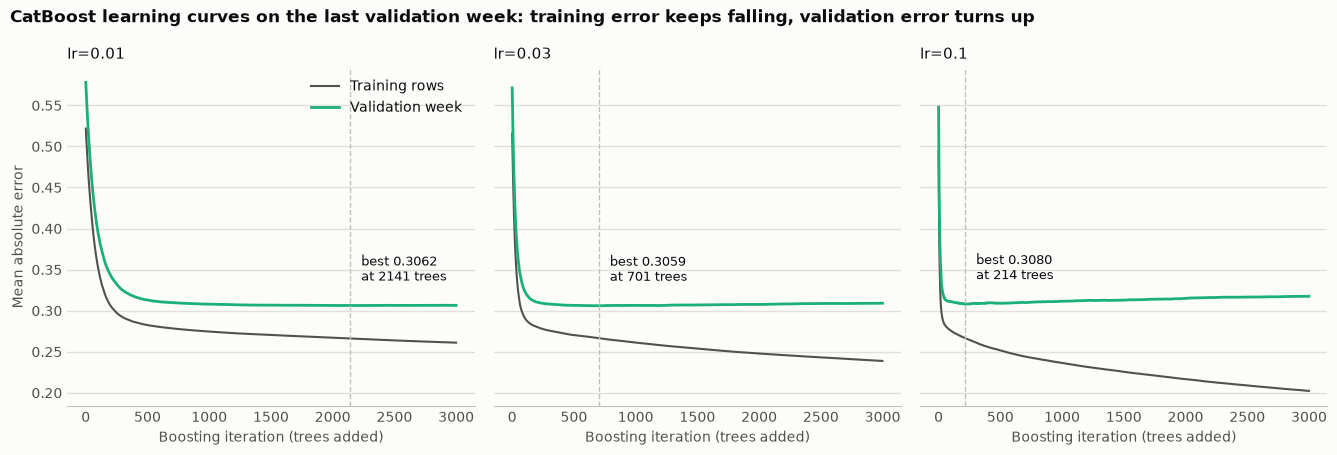

In [17]:
if RERUN_TUNING:
    tr5, va5 = ev.fold_split(train, 5)
    curves = {f"lr={r}": models.catboost_learning_curve(tr5, va5, depth=CAT_BEST["depth"], learning_rate=r, iterations=3000) for r in (0.01, 0.03, 0.1)}
    pd.concat(curves, axis=1).to_csv(C.RESULTS / "catboost_learning_curves.csv")
else:
    lc = pd.read_csv(C.RESULTS / "catboost_learning_curves.csv", header=[0, 1], index_col=0)
    curves = {label: lc[label] for label in lc.columns.levels[0]}
fig = plots.plot_learning_curves(curves, save=C.RESULTS / "catboost_learning_curves.png")
print(pd.DataFrame({label: {"best validation MAE": c.validation.min(), "at iteration": c.validation.idxmin(), "validation at 3000": c.validation.iloc[-1], "training at 3000": c.train.iloc[-1]} for label, c in curves.items()}).T.round(4))

This is the gradient-descent picture kNN and the forest could not give us. Training error keeps falling all the way to 3,000 trees, while validation error reaches a minimum and then rises: the later trees fit noise in the training rows. The faster the learning rate, the earlier the turn (about 200 trees at 0.1, 700 at 0.03, 2,000 at 0.01) and the worse the over-fitting at the end. The chosen 500 trees at 0.03 sits just before the minimum on this fold, which is where the five-fold grid also put it.

### Locked CatBoost design

- 10 features, no scaling
- **Depth 5, learning rate 0.03, 500 trees**, squared-error objective, CatBoost defaults otherwise

In [18]:
cat_val = cat1b[(cat1b.depth == CAT_BEST["depth"]) & (cat1b.learning_rate == CAT_BEST["learning_rate"]) & (cat1b.iterations == CAT_BEST["iterations"])].set_index("fold")
display(pd.DataFrame({"CatBoost": cat_val[["mae", "wape", "mse"]].mean(), "Random forest": rf_val[["mae", "wape", "mse"]].mean(),
                      "kNN": knn_val[["mae", "wape", "mse"]].mean(), "Baseline": baseline.mean()}).T.round(4))

,mae,wape,mse
CatBoost,0.3033,0.3183,0.2211
Random forest,0.3024,0.3174,0.2189
kNN,0.3120,0.3273,0.2375
Baseline,0.3284,0.3447,0.2701


On validation CatBoost is a hair behind the forest (0.3033 against 0.3024), inside the noise. Two very different tree methods have landed on the same error, which suggests the limit is in the features and the data rather than the model.

## 11. Ensemble of random forest and CatBoost

**Idea.** The forest averages many deep, independent trees; boosting stacks shallow, dependent ones. If their mistakes differ, averaging the two predictions cancels some of each. How much they differ is measurable: the correlation between their errors on the validation rows.

**Method.** Rather than refitting a combined model for every weight, each locked model is fitted once per fold and its validation predictions are stored (*out-of-fold predictions*, `ev.oof_predictions`). Any weighted average can then be scored instantly (`ev.score_blend`).

Correlation between the models' errors on the validation rows


,rf,catboost,knn
rf,1.000,0.969,0.950
catboost,0.969,1.000,0.934
knn,0.950,0.934,1.000


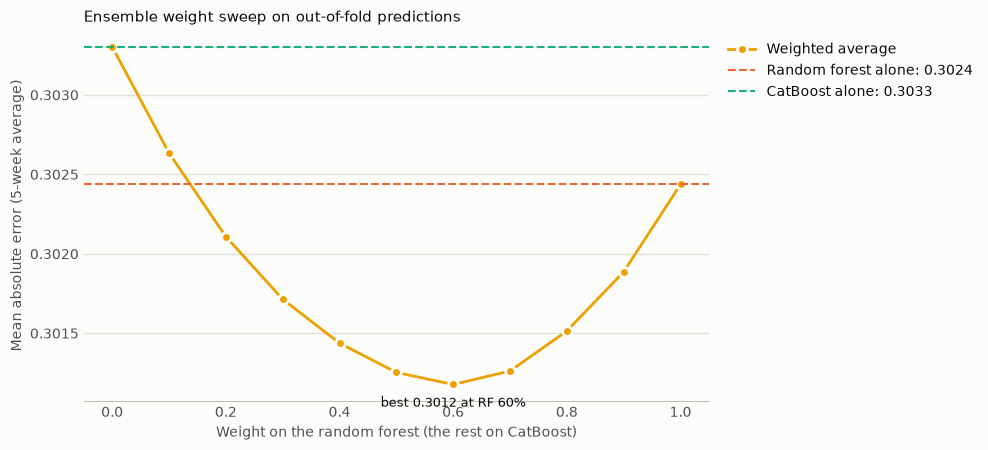

In [19]:
if RERUN_TUNING:
    oof = {"rf": ev.oof_predictions(feat, models.make_rf), "catboost": ev.oof_predictions(feat, models.make_catboost, CAT_BEST), "knn": ev.oof_predictions(feat, models.make_knn, {"k": KNN_K})}
    pd.concat({k: v.pred for k, v in oof.items()} | {"actual": oof["rf"][C.TARGET], "fold": oof["rf"].val_fold}, axis=1).to_csv(C.RESULTS / "oof_predictions.csv", index=False)
    sweep = pd.DataFrame([{"rf_weight": w / 10, "mae": ev.score_blend({"rf": oof["rf"], "catboost": oof["catboost"]}, {"rf": w / 10, "catboost": 1 - w / 10}).mean()} for w in range(11)]).set_index("rf_weight")
    sweep.to_csv(C.RESULTS / "ensemble_weight_sweep.csv")
else:
    sweep = pd.read_csv(C.RESULTS / "ensemble_weight_sweep.csv", index_col=0)
oof_table = pd.read_csv(C.RESULTS / "oof_predictions.csv")

errors = oof_table[["rf", "catboost", "knn"]].sub(oof_table.actual, axis=0)
print("Correlation between the models' errors on the validation rows")
display(errors.corr().round(3))

fig = plots.plot_weight_sweep(sweep, rf_val.mae.mean(), cat_val.mae.mean(), save=C.RESULTS / "ensemble_weight_sweep.png")

- The forest's and CatBoost's errors correlate at 0.97: they are mostly wrong on the same rows in the same direction. That caps what averaging can do.
- The sweep is a shallow U. Anything from 40% to 70% forest is within 0.0002 of the best; **50/50 is taken** as the simplest choice, and it is also what the main branch selected.
- The gain is about 0.001 MAE over the forest alone. Small, but it shows up in the week-by-week view below. Adding kNN as a third member does not help (equal-weight three-way blend: 0.3015).

### Locked ensemble design

- Average of the locked forest and the locked CatBoost, equal weights (`models.make_ensemble`, a scikit-learn `VotingRegressor`).

In [20]:
oof_table["ensemble"] = (oof_table.rf + oof_table.catboost) / 2
ens_val = oof_table[["rf", "catboost", "ensemble"]].sub(oof_table.actual, axis=0).abs().groupby(oof_table.fold).mean()
ens_val.columns = ["Random forest", "CatBoost", "RF + CatBoost (50/50)"]
display(ens_val.rename(index=C.FOLD_LABELS).round(4))
print("Weeks in which the ensemble beats the forest:", int((ens_val.iloc[:, 2] < ens_val.iloc[:, 0]).sum()), "of 5;  beats CatBoost:", int((ens_val.iloc[:, 2] < ens_val.iloc[:, 1]).sum()), "of 5")

,Random forest,CatBoost,RF + CatBoost (50/50)
fold,,,
May 22–28,0.2898,0.2877,0.2876
May 29–Jun 4,0.2908,0.2923,0.2902
Jun 5–11,0.3356,0.3356,0.3342
Jun 12–18,0.2897,0.2946,0.2902
Jun 19–25,0.3061,0.3063,0.3040


Weeks in which the ensemble beats the forest: 4 of 5;  beats CatBoost: 5 of 5


## 12. Model comparison

### Validation weeks

Each locked model against the baseline in every validation week.

,Baseline (7-day average),kNN (k = 25),"Random forest (depth 10, leaf ≥ 3)","CatBoost (depth 5, lr 0.03, 500 trees)",RF + CatBoost (50/50)
fold,,,,,
May 22–28,0.309,0.295,0.290,0.288,0.288
May 29–Jun 4,0.316,0.299,0.291,0.292,0.290
Jun 5–11,0.362,0.350,0.336,0.336,0.334
Jun 12–18,0.327,0.301,0.290,0.295,0.290
Jun 19–25,0.328,0.316,0.306,0.306,0.304


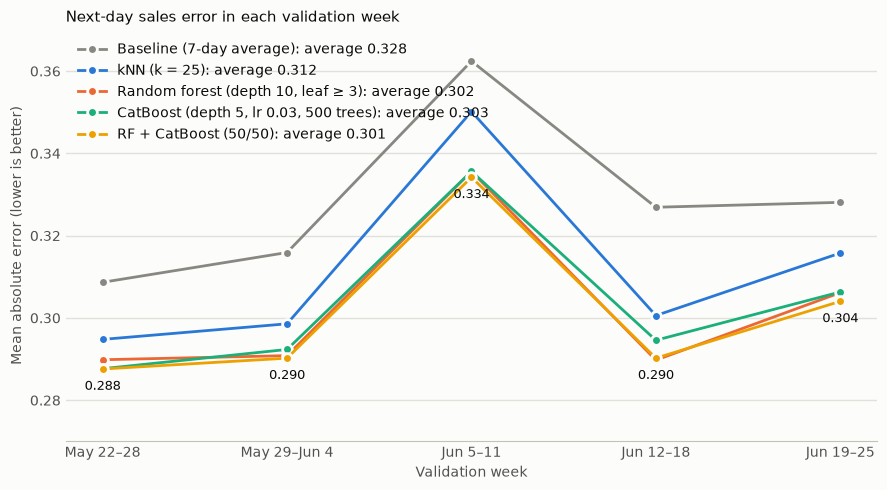

In [21]:
validation_mae = pd.DataFrame({
    "Baseline (7-day average)": baseline.mae,
    f"kNN (k = {KNN_K})": knn_val.mae,
    f"Random forest (depth {RF_DEPTH}, leaf ≥ {RF_LEAF})": rf_val.mae,
    "CatBoost (depth 5, lr 0.03, 500 trees)": ens_val["CatBoost"],
    "RF + CatBoost (50/50)": ens_val["RF + CatBoost (50/50)"],
})
colours = dict(zip(validation_mae.columns, [C.COLOURS["baseline"], C.COLOURS["knn"], C.COLOURS["rf"], C.COLOURS["catboost"], C.COLOURS["ensemble"]]))

display(validation_mae.rename(index=C.FOLD_LABELS).round(3))
fig = plots.plot_validation_weeks(validation_mae, colours, annotate=validation_mae.columns[-1], save=C.RESULTS / "validation_weeks.png")

The baseline and kNN sit clearly above the three tree models, which are bunched together in every week. The hard week (June 5–11) is hard for everyone.

### The unseen test week (June 26 – July 2)

Each locked model is fitted once on all training rows (April 4 – June 25) and scored on the test week. Every design choice above was made without looking at it. (One caveat shared with the main branch: this week has now been scored several times as models were added, so it is a shared benchmark rather than a never-seen set.)

In [22]:
test, fitted = ev.fit_predict_test(feat, {
    "knn": models.make_knn(KNN_K),
    "rf": models.make_rf(max_depth=RF_DEPTH, min_leaf=RF_LEAF),
    "catboost": models.make_catboost(**CAT_BEST),
    "ensemble": models.make_ensemble([("rf", models.make_rf(max_depth=RF_DEPTH, min_leaf=RF_LEAF)), ("catboost", models.make_catboost(**CAT_BEST))]),
})
methods = {"RF + CatBoost (50/50)": "pred_ensemble", "CatBoost": "pred_catboost", "Random forest": "pred_rf",
           "kNN (k=25)": "pred_knn", "Baseline (7-day mean)": "pred_baseline", "Same weekday last week": "pred_same_weekday"}

print(f"train rows: {len(ev.training_rows(feat)):,}   test rows: {len(test):,}")
overall = ev.score_methods(test, methods)
display(overall.round(4))
base_mae = overall.loc["Baseline (7-day mean)", "mae"]
display(((base_mae - overall.mae) / base_mae * 100).round(1).to_frame("MAE improvement over baseline, %"))

overall.to_csv(C.RESULTS / "test_summary.csv")
test[C.ROW_KEY + ["discount_next", C.TARGET, "target_stockout_hours", *methods.values()]].to_csv(C.RESULTS / "test_predictions.csv", index=False)

train rows: 25,896   test rows: 2,184


,mae,wape,mse,rmse
RF + CatBoost (50/50),0.2892,0.2986,0.2109,0.4593
CatBoost,0.2896,0.2990,0.2118,0.4603
Random forest,0.2923,0.3018,0.2158,0.4646
kNN (k=25),0.3040,0.3138,0.2401,0.4900
Baseline (7-day mean),0.3142,0.3244,0.2713,0.5209
Same weekday last week,0.3998,0.4127,0.3808,0.6171


,"MAE improvement over baseline, %"
RF + CatBoost (50/50),7.9
CatBoost,7.8
Random forest,7.0
kNN (k=25),3.2
Baseline (7-day mean),0.0
Same weekday last week,-27.2


- The ensemble and CatBoost are level at the top, about 8% ahead of the baseline on MAE and 22% on MSE. The forest is 1% behind them, kNN 4% behind the forest.
- CatBoost's edge over the forest on the test week (0.003) is larger than on validation (where the forest was 0.001 ahead). Both gaps are inside week-to-week noise; the honest reading is that the two tree models are equivalent and the ensemble is a safe way to not have to choose.

### By tomorrow's discount

The days that matter for phase 2 are the discounted ones.

In [23]:
print("MAE by tomorrow's discount")
display(ev.mae_by(test, methods, test.discount_band).round(3))
print("\nMean sales by tomorrow's discount: actual and predicted")
display(ev.mean_by(test, methods, test.discount_band).round(3))

MAE by tomorrow's discount


,RF + CatBoost (50/50),CatBoost,Random forest,kNN (k=25),Baseline (7-day mean),Same weekday last week,rows
discount_band,,,,,,,
deep (0.80 or lower),0.538,0.542,0.546,0.581,0.561,0.659,241
moderate (0.80-0.95],0.298,0.297,0.301,0.309,0.303,0.380,757
none (above 0.95),0.233,0.234,0.235,0.245,0.271,0.360,1186



Mean sales by tomorrow's discount: actual and predicted


,target_sales,pred_ensemble,pred_catboost,pred_rf,pred_knn,pred_baseline,pred_same_weekday
discount_band,,,,,,,
deep (0.80 or lower),1.659,1.588,1.609,1.567,1.495,1.391,1.318
moderate (0.80-0.95],0.997,1.019,1.011,1.027,0.987,0.998,1.009
none (above 0.95),0.810,0.808,0.799,0.816,0.805,0.887,0.912


- All three tree models beat the baseline on deep-discount days; kNN does not. The ensemble has the lowest deep-discount error.
- CatBoost comes closest to the size of the deep-discount spike (1.61 predicted against 1.66 actual; the forest says 1.57, the baseline 1.39). It also puts twice the importance on tomorrow's discount that the forest does (next table), which is why.
- On moderate discounts every model is within 0.005 of the baseline. Nothing has learned to beat the 7-day average there.

### By day and by store

In [24]:
print("MAE by day")
display(ev.mae_by(test, methods, test.dt.dt.strftime("%m-%d %a")).round(3))
print("\nMAE by store")
display(ev.mae_by(test, methods, test.store_id).round(3))

MAE by day


,RF + CatBoost (50/50),CatBoost,Random forest,kNN (k=25),Baseline (7-day mean),Same weekday last week,rows
dt,,,,,,,
06-26 Wed,0.274,0.268,0.282,0.287,0.315,0.395,312
06-27 Thu,0.244,0.242,0.247,0.267,0.279,0.371,312
06-28 Fri,0.285,0.287,0.286,0.285,0.283,0.380,312
06-29 Sat,0.325,0.326,0.330,0.347,0.342,0.456,312
06-30 Sun,0.345,0.344,0.348,0.359,0.403,0.463,312
07-01 Mon,0.266,0.271,0.265,0.272,0.276,0.319,312
07-02 Tue,0.285,0.289,0.287,0.311,0.300,0.414,312



MAE by store


,RF + CatBoost (50/50),CatBoost,Random forest,kNN (k=25),Baseline (7-day mean),Same weekday last week,rows
store_id,,,,,,,
18,0.294,0.300,0.295,0.310,0.313,0.397,448
154,0.256,0.255,0.261,0.261,0.258,0.326,420
182,0.291,0.291,0.293,0.300,0.329,0.411,427
235,0.280,0.279,0.286,0.301,0.310,0.394,441
343,0.323,0.322,0.326,0.345,0.358,0.467,448


### What the tree models rely on

In [25]:
display(pd.DataFrame({"Random forest": models.feature_importance(fitted["rf"]),
                      "CatBoost": models.feature_importance(fitted["catboost"]) / 100}).round(3).sort_values("Random forest", ascending=False))

,Random forest,CatBoost
sales_mean7,0.434,0.336
sales_mean_to_date,0.209,0.174
sales_t,0.139,0.127
discount_next,0.105,0.204
sales_lag7,0.059,0.041
discount_t,0.021,0.045
weekday_next,0.015,0.034
holiday_next,0.008,0.020
stockout_hours_t,0.008,0.015
activity_t,0.002,0.005


Both rank the 7-day average first and sales history before anything else. CatBoost gives tomorrow's discount 20% of its importance against the forest's 10%, consistent with its better deep-discount predictions. This matches the kNN feature-removal test, where tomorrow's discount was the most important single feature.

### Summary figure

,RF + CatBoost (50/50),CatBoost,Random forest,kNN (k=25),Baseline (7-day mean)
Validation\n(5-week average),0.301,0.303,0.302,0.312,0.328
Test week\n(all rows),0.289,0.290,0.292,0.304,0.314
"Test: no discount\n(1,186 rows)",0.233,0.234,0.235,0.245,0.271
Test: moderate discount\n(757 rows),0.298,0.297,0.301,0.309,0.303
Test: deep discount\n(241 rows),0.538,0.542,0.546,0.581,0.561


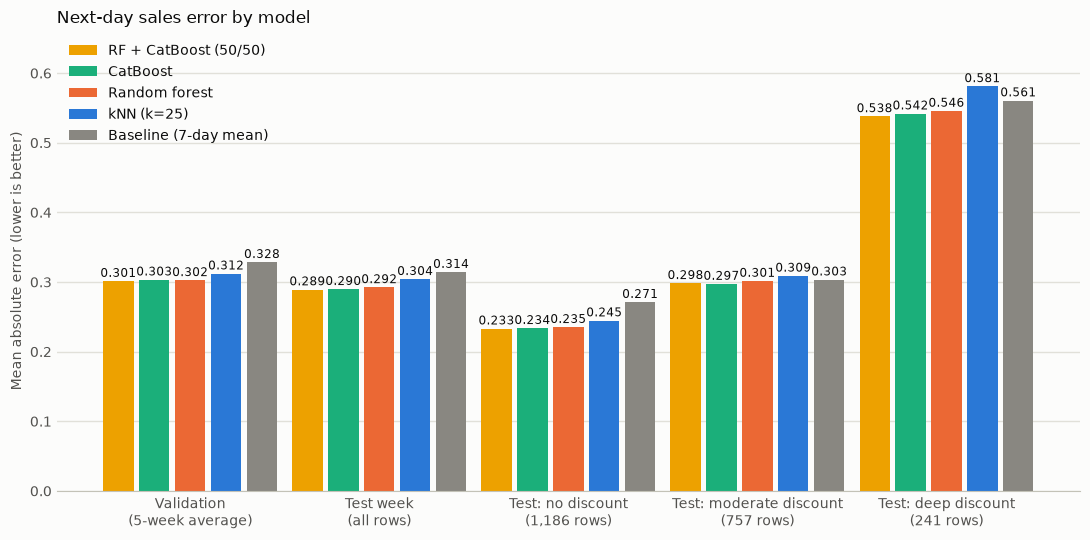

In [26]:
compare = {label: col for label, col in methods.items() if col != "pred_same_weekday"}
validation_avg = {"RF + CatBoost (50/50)": ens_val.iloc[:, 2].mean(), "CatBoost": cat_val.mae.mean(), "Random forest": rf_val.mae.mean(),
                  "kNN (k=25)": knn_val.mae.mean(), "Baseline (7-day mean)": baseline.mae.mean()}
palette = {"RF + CatBoost (50/50)": C.COLOURS["ensemble"], "CatBoost": C.COLOURS["catboost"], "Random forest": C.COLOURS["rf"],
           "kNN (k=25)": C.COLOURS["knn"], "Baseline (7-day mean)": C.COLOURS["baseline"]}
fig, table = plots.plot_model_comparison(validation_avg, test, compare, palette, save=C.RESULTS / "model_comparison.png")
display(table.round(3))

## 13. Findings and limits

1. **Success test met by every model.** All four beat the 7-day average on validation and on the test week.
2. **Best model: the 50/50 forest + CatBoost ensemble**, with CatBoost alone effectively tied. Test-week MAE 0.289 against 0.314 for the baseline (8% lower), MSE 22% lower.
3. **The three tree models are equivalent within noise.** Validation 0.3013 to 0.3033; the spread across seeds and weeks is larger than the spread across models. Two unrelated tree methods reaching the same error says the ceiling is in the features and the data.
4. **Feature choice mattered more than any setting, for every model.** Removing weather was the largest single gain; k, depth, leaf size, learning rate and iterations all moved MAE by less than week-to-week noise.
5. **Boosting over-fits visibly; forests do not.** The learning curve turns up after a few hundred trees, which is why the best CatBoost is small and slow. The forest got no worse with more or deeper trees.
6. **Ensembling buys little here** because the two models' errors correlate at 0.97. The 0.001 gain is real across weeks but small.
7. **Deep discounts remain the weak spot.** Errors there are more than twice the ordinary-day error for every model, and all still under-predict the spike. On moderate discounts no model beats the baseline.
8. **Selection optimism.** Many options were compared on the same five weeks, and the test week has now been scored for four models. The test figures are the honest ones but no longer pristine.
9. **Scope.** Five stores in one city, one test week. Results may not carry to other cities or seasons.

## 14. Comparison with the main branch

Yuanyuan Yin's project on `main` (`01_freshretail_project.ipynb`, results under `outputs/`) reconstructs this protocol independently from the written notes: the same 312 series, the same five weekly folds, the same ten inputs under different names, and the same baselines. It compares five models (Ridge, decision tree, random forest, HistGradientBoosting, CatBoost) and then explores blends. Side by side, from `outputs/final_protocol/model_comparison_test.csv`, `chosen_parameters.csv` and `outputs/ensemble_exploration/*.csv`:

| Model | Main branch design | Main: validation / test MAE | This branch design | This branch: validation / test MAE |
|---|---|---|---|---|
| 7-day average baseline | – | 0.3284 / 0.3142 | – | 0.3284 / 0.3142 |
| Random forest | depth 10, leaf ≥ 5, 200 trees | 0.3037 / 0.2929 | depth 10, leaf ≥ 3, 300 trees, half the features per split | 0.3024 / 0.2923 |
| CatBoost | depth 4, lr 0.05, 400 trees, l2 = 5 | 0.3038 / 0.2878 | depth 5, lr 0.03, 500 trees | 0.3033 / 0.2896 |
| RF + CatBoost (50/50) | equal weights | 0.3014 / 0.2873 | equal weights | 0.3013 / 0.2892 |
| HistGradientBoosting | lr 0.05, 300 iterations, 15 leaves | 0.3055 / 0.2892 | not run | – |

**What agrees.** The baselines are identical to four decimals, which confirms the two feature pipelines produce the same rows. Every shared model lands within 0.002 on both validation and test, and both branches pick the 50/50 blend as the best validation design. The deep-discount diagnostics agree too: the forest beats the baseline there by a few percent and under-predicts the spike.

**What differs.** The main branch's CatBoost is slightly better on the test week (0.2878 against 0.2896) with a smaller, more regularised design; given seed noise of 0.0005 on validation and one week of test data, this is not a meaningful gap. The main branch frames the final week as *already viewed* rather than unseen, which is the stricter and more accurate description now that several models have been scored on it. Its discount scenario (section 15) restricts candidates to rates the series has historically had, the same fix arrived at independently below.

**What this branch adds.** The tuning record for each model (why depth 10, why 500 trees, the learning curves), the error-correlation argument for why the ensemble gains so little, and the phase 2 draft on all 2,184 test rows rather than one illustrative store-product.

## 15. Phase 2, first draft: using the model to choose tomorrow's discount

**The idea.** For a store-product on the evening of day t, hold every known feature fixed and vary only tomorrow's discount. The model's prediction under each candidate is a what-if. Two decision rules are tried:

- *Max value*: pick the discount with the highest predicted sales × discount rate. This is a sales-value proxy, since `sale_amount` is normalised and there is no unit price.
- *Max sales within value*: pick the highest predicted sales among candidates whose predicted value is at least 95% of the value at no discount. This is the rule the main branch uses: "sell more, as long as it does not give away more than 5% of value".

The ensemble fitted in section 12 is the engine. Candidates: 1.0, 0.95, 0.9, 0.85, 0.8, 0.75, 0.7, 0.6. Discount bands follow the convention used in the test-week tables and on the main branch: **deep** is 0.80 or lower, **moderate** is above 0.80 up to 0.95, **none** is above 0.95. So the 0.80 candidate counts as deep and 0.95 as moderate.

In [27]:
from finalproject_pricingml import scenario

response = scenario.discount_response(fitted["ensemble"], test)
curve = scenario.response_curve(response)
display(curve.round(3))
print(f"Rows whose predicted sales never fall as the discount deepens: {scenario.monotonicity(response):.1%}")
print("\nUnrestricted 'max value' rule: recommended discount, count of store-product-days")
display(scenario.recommend(response, "max_value").discount.value_counts().sort_index(ascending=False).to_frame("rows").T)

,pred_sales,pred_value,sales_vs_no_discount,value_vs_no_discount
discount,,,,
1.00,0.826,0.826,1.000,1.000
0.95,0.972,0.923,1.177,1.118
0.90,1.009,0.908,1.222,1.100
0.85,1.068,0.907,1.293,1.099
0.80,1.125,0.900,1.362,1.090
0.75,1.197,0.897,1.449,1.087
0.70,1.439,1.007,1.743,1.220
0.60,1.918,1.151,2.323,1.394


Rows whose predicted sales never fall as the discount deepens: 97.8%

Unrestricted 'max value' rule: recommended discount, count of store-product-days


discount,1.00,0.95,0.90,0.85,0.70,0.60
rows,23,398,4,43,175,1541


**The trap.** Taken at face value the model says: discount everything, deeply. Predicted sales at 0.6 are 2.3× the no-discount level and the value proxy is 39% higher, so the unrestricted rule picks 0.6 for 70% of rows. This is extrapolation. Fewer than 1% of training rows have a discount below 0.6, and those rows are not ordinary days: they are the occasions on which a manager chose a deep discount, often clearance, where sales spiked. The model has learned that correlation faithfully. It has not learned what would happen if *any* product were discounted to 0.6 on an ordinary day, because that never happened in the data.

**First fix: stay inside each series' own history.** A candidate is allowed for a store-product only if that series had at least three training days within 0.025 of it. This is what the main branch's scenario does ("historically supported rates"), and it is the minimum needed to keep the what-if on ground the model has seen.

In [28]:
support = scenario.supported_candidates(train, min_days=3)
print("Share of the 312 series supporting each candidate discount, %")
display((support.mean() * 100).round(0).to_frame("series supporting it, %").T)
supported = scenario.restrict(response, support)
print(f"What-if rows: {len(response):,} unrestricted, {len(supported):,} supported (median {support.sum(axis=1).median():.0f} candidates per series)")

BANDS = ["deep", "moderate", "none"]
band = lambda d: pd.cut(d, C.DISCOUNT_BAND_EDGES, labels=BANDS)
actual = test.set_index(C.ROW_KEY).discount_next
at_no_discount = response[response.discount == 1.0].set_index(C.ROW_KEY).pred_sales.reindex(actual.index)
deepest_supported = supported.groupby(C.ROW_KEY).discount.min().reindex(actual.index)
RULES = {"Max value": ("max_value", {}), "Max sales, value ≥ 95% of no-discount": ("max_sales_within_value", {"min_value_share": 0.95})}
recs = {name: scenario.recommend(supported, rule, **kw).set_index(C.ROW_KEY).reindex(actual.index) for name, (rule, kw) in RULES.items()}

print("\nTable 1. Recommended discount under each rule, % of the 2,184 store-product-days in the test week")
display((pd.DataFrame({n: r.discount.value_counts(normalize=True) for n, r in recs.items()}).reindex(scenario.CANDIDATES).fillna(0).T * 100).round(1))

print("\nTable 2. What the recommendations amount to, % of days")
summary = {}
for name, rec in recs.items():
    a, b = band(actual).cat.codes, band(rec.discount).cat.codes  # 0 = deep, 1 = moderate, 2 = none
    summary[name] = {
        "recommends some discount": (rec.discount < 1).mean(),
        "picks the deepest supported candidate": (rec.discount.values == deepest_supported.values).mean(),
        "deeper band than the manager chose": (b < a).mean(),
        "same band as the manager": (b == a).mean(),
        "lighter band than the manager": (b > a).mean(),
        "mean predicted sales lift over no discount": (rec.pred_sales / at_no_discount).mean() - 1,
    }
display((pd.DataFrame(summary) * 100).round(1))

for name, rec in recs.items():
    print(f"\nTable 3. {name}: where the model's band lands, given what the manager actually did (rows sum to 100%)")
    ct = pd.crosstab(band(actual), band(rec.discount), normalize="index") * 100
    ct.index = [f"manager chose {b} ({(band(actual) == b).sum():,} days)" for b in ct.index]
    ct.columns = [f"model: {b}" for b in ct.columns]
    display(ct.round(0).astype(int))

Share of the 312 series supporting each candidate discount, %


,1.00,0.95,0.90,0.85,0.80,0.75,0.70,0.60
"series supporting it, %",100.0,79.0,77.0,69.0,41.0,23.0,12.0,5.0


What-if rows: 17,472 unrestricted, 8,883 supported (median 4 candidates per series)

Table 1. Recommended discount under each rule, % of the 2,184 store-product-days in the test week


discount,1.00,0.95,0.90,0.85,0.80,0.75,0.70,0.60
Max value,1.7,39.9,8.2,17.9,12.9,8.6,7.3,3.4
"Max sales, value ≥ 95% of no-discount",0.4,0.6,16.5,23.9,28.4,16.2,9.3,4.8



Table 2. What the recommendations amount to, % of days


,Max value,"Max sales, value ≥ 95% of no-discount"
recommends some discount,98.3,99.6
picks the deepest supported candidate,42.4,98.2
deeper band than the manager chose,62.1,72.3
same band as the manager,30.7,24.5
lighter band than the manager,7.2,3.3
mean predicted sales lift over no discount,44.0,50.7



Table 3. Max value: where the model's band lands, given what the manager actually did (rows sum to 100%)


,model: deep,model: moderate,model: none
manager chose deep (241 days),37,59,5
manager chose moderate (757 days),25,74,1
"manager chose none (1,186 days)",36,62,2



Table 3. Max sales, value ≥ 95% of no-discount: where the model's band lands, given what the manager actually did (rows sum to 100%)


,model: deep,model: moderate,model: none
manager chose deep (241 days),71,28,2
manager chose moderate (757 days),52,48,0
"manager chose none (1,186 days)",60,39,0


**Reading the tables.**

- **The model wants a discount almost every day.** Both rules recommend one on more than 98% of days, including 98% of the days on which the manager chose none (Table 3, bottom row). The predicted lift at the recommended discount averages 44–51% over no discount.
- **The value constraint does not constrain.** Under the 95%-of-value rule the model picks the deepest candidate the product has ever run on 98% of days (Table 2). The model predicts value *rising* with discount for nearly every row (the response curve above), so a floor at 95% of the no-discount value is never reached, and the rule collapses to "go as deep as this product has gone before". The max-value rule is more moderate only because its objective trades volume against price: it settles on 0.95 or 0.85 for most days.
- **Support restriction decides where, not whether.** Compared with the unrestricted result (0.60 on 70% of days), restriction moves the mass to 0.85–0.95 under the max-value rule and 0.80–0.90 under the value rule. The 0.60 candidate is still recommended on nearly every day where it is supported; it is only supported for 5% of series.
- **The model's advice barely depends on what the manager did.** Each row of Table 3 looks much like the others: under the max-value rule the model recommends a deep discount on 37% of the days the manager went deep, 25% of moderate days and 36% of no-discount days. Managers clearly discount selectively, using information about the product and the day. The what-if does not see that information, so it cannot reproduce their selectivity, and agreement with their actual band is only 25–31%.

**Why this is not evidence that the managers are wrong.** In the training data, discounts were applied on days when managers expected or observed demand, so part of the lift the model has learned is manager judgement rather than the effect of the discount. The what-if then attributes all of it to the discount and recommends discounting everywhere. Without an experiment, or at least a within-series check (next list), the response curve is a description of past co-occurrence, not a forecast of what a new discount would do.

**What phase 2 still needs before it can be presented as a recommendation.**

1. **A margin assumption.** Sales × discount rewards volume. With a unit cost *c* the objective becomes (discount − c) × sales, which penalises deep discounts and would bring "no discount" back into play for many rows. The cost is unknown, so this has to be a scenario parameter.
2. **A causal check that the data allows.** The cleanest option is within-series: compare each series' sales on discounted and non-discounted days with similar history, and see whether the model's predicted lift matches the observed lift per series. This would show where the model's response is supported and where it is inherited from manager timing.
3. **Uncertainty.** The forest's 300 trees give a prediction spread for free. A rule that only recommends a discount when the predicted lift clears the spread would stop the model acting on 0.001 differences, which the main branch's illustrative case also flagged.
4. **Stockouts.** The target is observed sales, censored by stock. Rows with stockout hours should be excluded from the response curve or the recommendation should be capped by stock on hand, which the data does not have.

## 16. Next steps

1. Decide with the team which branch's notebook is the submission and fold the other's unique parts into it (sections 14 and 15 above are the candidates from this side).
2. Phase 2: add the margin parameter and the within-series lift check, then rerun the recommendation table.
3. If time allows, a later untouched week from the dataset would restore a genuinely unseen test.

## Appendix: reproducing this notebook

| Where | What |
|---|---|
| `src/finalproject_pricingml/data.py` | Series selection, cleaning, features, splits |
| `src/finalproject_pricingml/evaluate.py` | Metrics, time-ordered cross-validation, out-of-fold predictions, blend scoring, test-week scoring |
| `src/finalproject_pricingml/models.py` | One factory per model: kNN, random forest, CatBoost, ensemble; learning curves |
| `src/finalproject_pricingml/scenario.py` | Phase 2 what-if: discount response, support restriction, decision rules |
| `src/finalproject_pricingml/plots.py` | The figures |
| `results/` | Every tuning grid, the out-of-fold predictions, test-week predictions and the figures |
| `docs/` | The original build-out notes for kNN and the random forest |

Set `RERUN_TUNING = True` in the first cell to recompute every grid from scratch (two to three minutes). The one-off checks quoted in sections 6, 8 and 9 were run interactively and are not scripted.